# Multi-core exploration — template

Copy this notebook, change the **Configuration** cell, run all.

- `multi_core_runs.py`: `generate_problem`, `run_single`, `run_grid`, `run_study`, `build_hierarchy`, `trace_sweeps`
- `multi_core_utils.py`: configs, saved runs (`save_run`, `load_run`), plots

A **point** is `(nb_partitions, nb_node_per_meta_nodes)`. The point `(1, 0)` is the single-core baseline: it is solved with the plain Multiplicative solver instead of the hierarchical one.

The problem is generated once and every point solves a copy of it, so all the points of a run see exactly the same model.

In [1]:
%load_ext autoreload
%autoreload 2 --full
%matplotlib inline

import multi_core_runs as runs   # sets TOP, one BLAS thread per process, no per-trial progress bars
import multi_core_utils as utils

## Configuration

`config` is the base yaml with the changes below. Any other key of the yaml can be passed to `make_config` the same way; a key that is not in the yaml raises an error.

`NB_CONNECTION_PER_SPIN` and `NB_SWEEPS` take one value or a list of values. The sections on one problem (problem, single run, hierarchy, sweeps) use the first value; the study runs all of them.

In [2]:
PROBLEM_TYPE = "Maxcut"
BASE_CONFIG = "maxcut_c1"         # a yaml of config_files/, or a path
FILE_COMMENT = "all_range_trials"
SIZE = 1024                       # number of spins
#NB_CONNECTION_PER_SPIN = [1023,      # spins a spin is coupled to: one value or a list, e.g. [1023, 512, 205]
NB_RUNS = 20                      # trials per point (about 2 to 7 s per trial at 1024 spins)

NB_PARTITIONS = [ 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024] 
NB_NODE_PER_META_NODES = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]   
NB_SWEEPS = [2]             # upper-then-partitions cycles of the hierarchical solver: one value or a list

NB_WORKERS = None                 # points solved at the same time; None: all CPUs, 1: in this process
NICE = 0                          # positive on a shared server
RESULTS_DIR = utils.RESULTS_DIR   # where the runs are saved

# Fraction of the other spins a spin is coupled to, for each number of connections per spin
CONNECTIVITY = [1.0,0.05] #[connections / (SIZE - 1) for connections in utils.as_list(NB_CONNECTION_PER_SPIN)]

config = utils.make_config(
    utils.load_config(BASE_CONFIG),
    PROBLEM_TYPE,
    dummy_size=SIZE,
    dummy_connectivity=CONNECTIVITY[0],
    nb_runs=NB_RUNS,
    nb_sweeps_Hierarchical_solver=utils.as_list(NB_SWEEPS)[0],
)
grid = utils.make_grid(NB_PARTITIONS, NB_NODE_PER_META_NODES, baseline=True)
print(f"{len(grid)} points, {len(utils.as_list(NB_SWEEPS))} numbers of sweeps, connectivity {[round(value, 3) for value in CONNECTIVITY]}")

101 points, 1 numbers of sweeps, connectivity [1.0, 0.05]


## Problem

Generated once. The connections per spin are counted on the generated `J`.

In [3]:
problem = runs.generate_problem(config)
model = problem["ising_model"]
print(f"{PROBLEM_TYPE}: {model.num_variables} spins, {utils.connections_per_spin(model):.1f} connections per spin")

Maxcut: 1024 spins, 1023.0 connections per spin


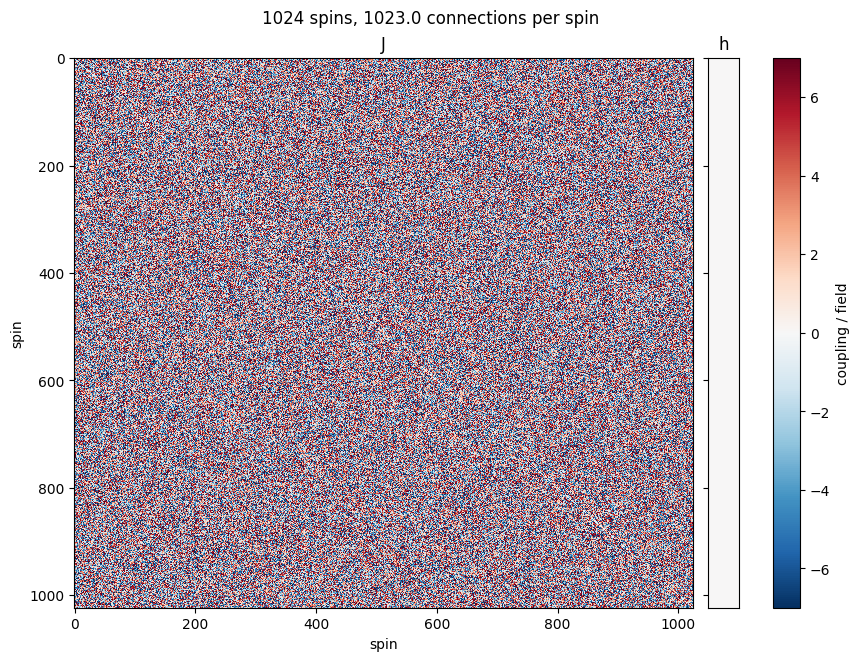

In [4]:
fig = utils.plot_model(model)

## Single run

One point, in this process. The row gives the point, what it means in spins, and the MIN / 25 % / 50 % / 75 % / MAX of the trial energies.

`nb_node_per_meta_nodes` is the number of nodes (spins) grouped in one meta node. The pipeline config calls it `nb_meta_nodes`; it builds `num_spins // nb_node_per_meta_nodes` meta nodes in total (`total_meta_nodes`), shared between the partitions.

In [5]:
#row = runs.run_single(problem, nb_partitions=32, nb_node_per_meta_nodes=32)
#row

The hierarchy of that point, as the solver builds it before the first sweep: the `J` and `h` of the meta nodes (upper model), then of each partition, with their smallest and largest value underneath. The `h` of a partition is the one of the problem here; the influence of the other partitions is added during the sweeps.

With `partitioning_technique: random` the partitions are drawn again at each trial, so this is then one example.

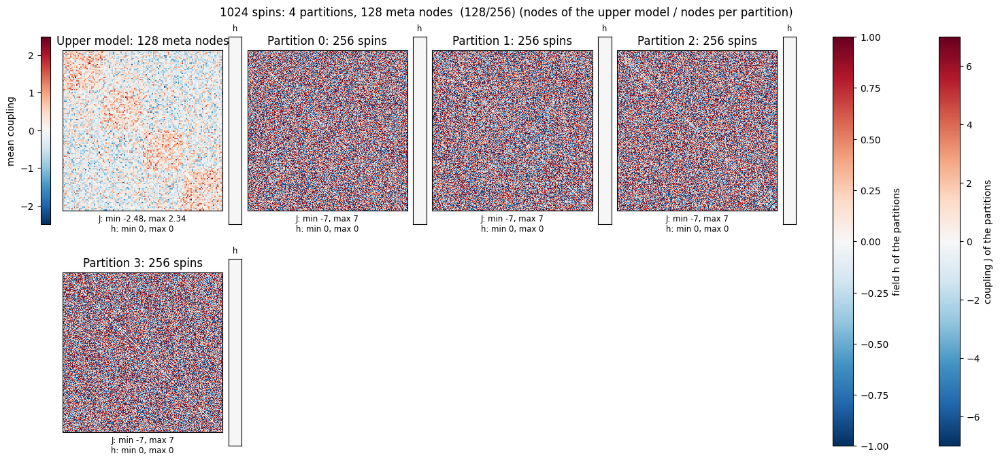

In [7]:
hierarchy = runs.build_hierarchy(problem, nb_partitions=4, nb_node_per_meta_nodes=8)
fig = utils.plot_hierarchy(hierarchy)

The `J` and `h` at sweeps 0, 1, 2, 3 of the first trial, recorded while the solver runs. One row per sweep: the upper model on its own scales, the upper model on the scales of the partitions, then each partition with the `h` it is given at that sweep. The smallest and largest `J` and `h` are under each model; the title gives the largest change since sweep 0.

`plot_sweep_diff` shows the difference between two sweeps (`second` minus `first`): `J`, `h`, and the spins `s` that flipped.

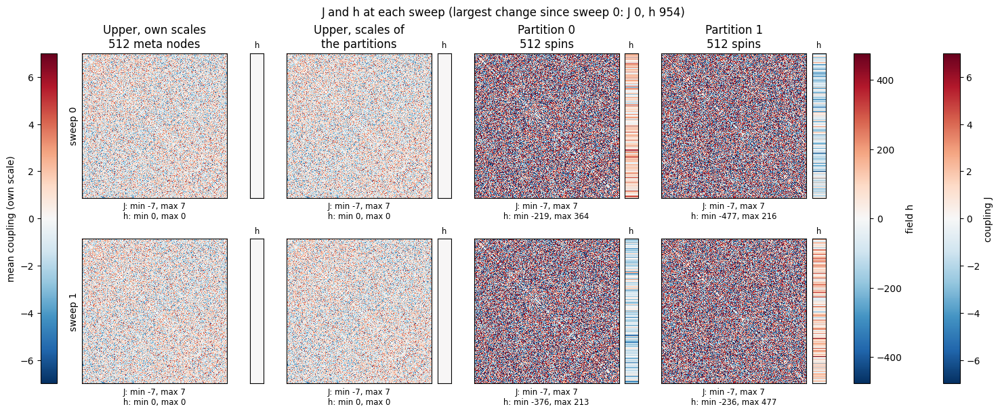

In [8]:
trace = runs.trace_sweeps(problem, nb_partitions=2, nb_node_per_meta_nodes=2, nb_sweeps=2)
fig = utils.plot_sweep_couplings(trace)

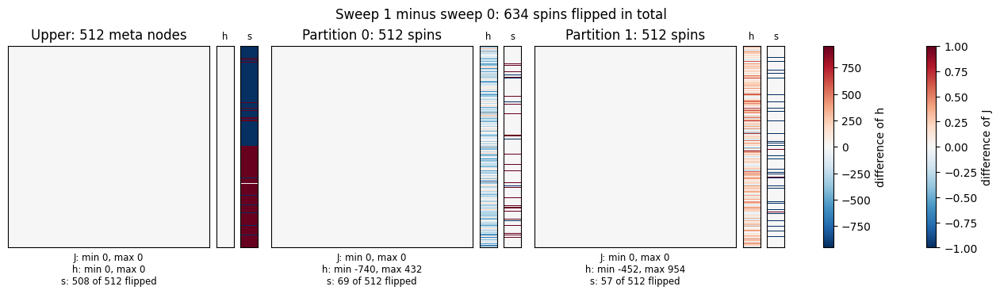

In [9]:
fig = utils.plot_sweep_diff(trace, first=0, second=1)

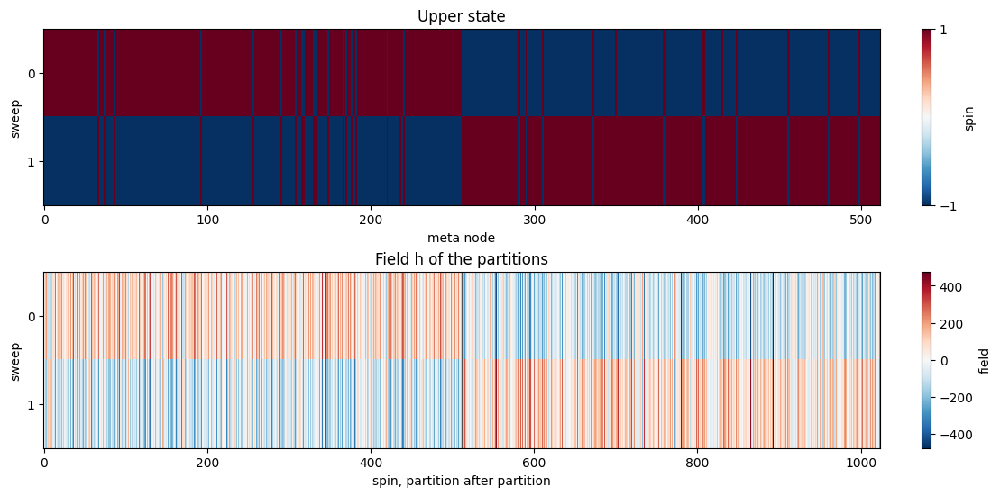

In [10]:
fig = utils.plot_sweep_fields(trace)

## Profile of a small study

Where the time of a study goes. A small grid is solved with `run_study`, as in **Study** below, under `cProfile`, with three differences: the points are solved one after the other in this process (the profiler does not see the workers), for `PROFILE_TRIALS` trial(s) instead of `NB_RUNS`, and nothing is saved: no live run, no csv.

`cumtime` is the time spent in a function and in everything it calls, `tottime` the time in the function itself. The times are longer than in a normal run: the profiler slows the Python code down (loops, small functions), not the numpy calls.

In [158]:
import cProfile
import pstats
import sys

PROFILE_PARTITIONS = [4, 8]
PROFILE_NODES_PER_META_NODE = [4, 8]
PROFILE_SWEEPS = 2
PROFILE_TRIALS = 1                       # trials per point
PROFILE_CONNECTIVITY = CONNECTIVITY[0]   # one connectivity, or a list as in the study

profile_config = dict(config, nb_runs=PROFILE_TRIALS)
profile_grid = utils.make_grid(PROFILE_PARTITIONS, PROFILE_NODES_PER_META_NODE, baseline=False)
# A profiler left on by a run of this cell that was interrupted would refuse a new one
sys.monitoring.free_tool_id(sys.monitoring.PROFILER_ID)
with cProfile.Profile() as profiler:
    profile_frame = runs.run_study(
        profile_config, profile_grid, nb_sweeps=PROFILE_SWEEPS, connectivity=PROFILE_CONNECTIVITY, nb_workers=1
    )
profile_stats = pstats.Stats(profiler).strip_dirs()
profile_frame[["connectivity", "nb_partitions", "nb_node_per_meta_nodes", "nb_sweeps", "nb_trials", "en_50", "time_mean"]]

connectivity 1.0: 1024 spins, 1023.0 connections per spin


Grid points: 100%|██████████| 4/4 [01:29<00:00, 22.34s/it]


,connectivity,nb_partitions,nb_node_per_meta_nodes,nb_sweeps,nb_trials,en_50,time_mean
0,1.0,4,4,2,1,-43396.0,37.428904
1,1.0,4,8,2,1,-37332.0,25.278265
2,1.0,8,4,2,1,-66722.0,31.978854
3,1.0,8,8,2,1,-60828.0,27.721021


In [159]:
# The 30 functions with the most time in them and in what they call
profile_stats.sort_stats("cumulative").print_stats(30)

         219793380 function calls (158858196 primitive calls) in 89.811 seconds

   Ordered by: cumulative time
   List reduced from 713 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   89.810   89.810 multi_core_runs.py:1(run_study)
        1    0.000    0.000   89.345   89.345 multi_core_runs.py:1(run_grid)
        4    0.263    0.066   89.339   22.335 multi_core_runs.py:1(_run_point)
        4    0.038    0.009   89.076   22.269 multi_core_runs.py:1(run_single)
6031174/5    0.989    0.000   76.600   15.320 {built-in method builtins.next}
        8    0.000    0.000   76.139    9.517 quantization_stage.py:33(run)
        8    0.000    0.000   76.138    9.517 combine_nodes_stage.py:25(run)
        8    0.000    0.000   76.137    9.517 mismatch_stage.py:23(run)
        8    0.000    0.000   76.137    9.517 simulation_stage.py:54(run)
        4    0.000    0.000   76.136   19.034 simulation_stage.py:130(

In [163]:
# The 20 functions that take the most time themselves, without what they call
profile_stats.sort_stats("tottime").print_callers(20)


   Ordered by: internal time
   List reduced from 713 to 20 due to restriction <20>

Function                                                    was called by...
                                                                ncalls  tottime  cumtime
Multiplicative.py:90(inner_loop_FE)                         <- 2705/1290   27.967   32.397  Multiplicative.py:174(solve)
                                                                  92/9    0.783    0.257  base_events.py:1909(_run_once)
                                                                     1    0.015    0.042  threading.py:637(wait)
shape_base.py:477(_block_check_depths_match)                <- 8043252/4023978    5.424    8.579  shape_base.py:522(<genexpr>)
                                                               2011989    2.498   13.303  shape_base.py:879(_block_setup)
copy.py:118(deepcopy)                                       <- 8649/11    0.006    0.000  base_events.py:1909(_run_once)
                        

In [ ]:
# Who calls np.block (shape_base.py), up to run_study. An indented line is a caller of the line above it,
# with the calls it made to it and the time spent in it for those calls. A function is expanded once.
def print_caller_tree(stats, function, edge=None, depth=0, seen=None):
    seen = set() if seen is None else seen
    file, line, name = function
    info = f"  [{edge[0]} calls, {edge[3]:.3f} s]" if edge else ""
    again = "  (callers shown above)" if function in seen and stats.stats[function][4] else ""
    print(f"{'  ' * depth}{file}:{line}({name}){info}{again}")
    if function in seen:
        return
    seen.add(function)
    for caller, caller_edge in sorted(stats.stats[function][4].items(), key=lambda item: -item[1][3]):
        print_caller_tree(stats, caller, caller_edge, depth + 1, seen)


block = next(function for function in profile_stats.stats if function[0] == "shape_base.py" and function[2] == "block")
print_caller_tree(profile_stats, block)

## Study

All the points, for every number of sweeps and every connectivity, in parallel. One problem is generated per connectivity (same seed), with its own single-core baseline; for the numbers of sweeps, each point is solved once with the largest one and the energy after each listed number of sweeps is kept.

`save_run` writes a yaml (the config, with the grid and the lists) and a csv (the table) under a verbose name with a timestamp, and links `last_run.yaml` / `last_run.csv` to them.

In [19]:
frame = runs.run_study(config, grid, nb_sweeps=NB_SWEEPS, connectivity=CONNECTIVITY, nb_workers=NB_WORKERS, nice=NICE, live_folder=RESULTS_DIR)
config_path, csv_path = utils.save_run(config, frame, RESULTS_DIR)
print(config_path.name)
print(csv_path.name)

Live run: /Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/study_hierarchy/Multi_core_architecture/01_meeting_1_results/results/live_run.csv, updated after each point (load_run("live_run"))
connectivity 1.0: 1024 spins, 1023.0 connections per spin


Grid points:   8%|▒░░░░░░░░░| 8/101 [00:30<08:54,  5.75s/it]

Point (nb_partitions=2, nb_node_per_meta_nodes=1024) of connectivity 1: not solved, going on with the next point
    ValueError: Each subproblem needs at least one upper node
    raised in make_hierarchy (ising/solvers/Hierarchical_solver.py:228), called from solve (ising/solvers/Hierarchical_solver.py:141), called from run_solver (ising/stages/simulation_stage.py:325)


Grid points:  10%|▒░░░░░░░░░| 10/101 [00:34<03:20,  2.20s/it]

Point (nb_partitions=4, nb_node_per_meta_nodes=512) of connectivity 1: not solved, going on with the next point
    ValueError: Each subproblem needs at least one upper node
    raised in make_hierarchy (ising/solvers/Hierarchical_solver.py:228), called from solve (ising/solvers/Hierarchical_solver.py:141), called from run_solver (ising/stages/simulation_stage.py:325)


...

Point (nb_partitions=512, nb_node_per_meta_nodes=512) of connectivity 0.05: not solved, going on with the next point
    LinAlgError: The leading minor of order 4 of B is not positive definite. The factorization of B could not be completed and no eigenvalues or eigenvectors were computed.
    raised in eigh (linalg/_decomp.py:593), called from partition_by_eigenvector (ising/utils/partitioning_schemes.py:72), called from partition_by_eigenvector (ising/utils/partitioning_schemes.py:79)
Point (nb_partitions=512, nb_node_per_meta_nodes=256) of connectivity 0.05: not solved, going on with the next point
    LinAlgError: The leading minor of order 4 of B is not positive definite. The factorization of B could not be completed and no eigenvalues or eigenvectors were computed.
    raised in eigh (linalg/_decomp.py:593), called from partition_by_eigenvector (ising/utils/partitioning_schemes.py:72), called from partition_by_eigenvector (ising/utils/partitioning_schemes.py:79)
Point (nb_partitio

Grid points:  93%|█████████░| 94/101 [00:59<00:00, 17.74it/s]

Point (nb_partitions=1024, nb_node_per_meta_nodes=32) of connectivity 0.05: not solved, going on with the next point
    ValueError: Each subproblem needs at least one upper node
    raised in make_hierarchy (ising/solvers/Hierarchical_solver.py:228), called from solve (ising/solvers/Hierarchical_solver.py:141), called from run_solver (ising/stages/simulation_stage.py:325)
Point (nb_partitions=1024, nb_node_per_meta_nodes=256) of connectivity 0.05: not solved, going on with the next point
    ValueError: Each subproblem needs at least one upper node
    raised in make_hierarchy (ising/solvers/Hierarchical_solver.py:228), called from solve (ising/solvers/Hierarchical_solver.py:141), called from run_solver (ising/stages/simulation_stage.py:325)
Point (nb_partitions=1024, nb_node_per_meta_nodes=512) of connectivity 0.05: not solved, going on with the next point
    ValueError: Each subproblem needs at least one upper node
    raised in make_hierarchy (ising/solvers/Hierarchical_solver.py:

Grid points: 100%|██████████| 101/101 [01:12<00:00,  1.39it/s]

Maxcut_N1024_c1-0.05_p2-4-8-16-32-64-128-256-512-1024_m2-4-8-16-32-64-128-256-512-1024_sweeps2_runs20_modularity_20261009_084417.yaml
Maxcut_N1024_c1-0.05_p2-4-8-16-32-64-128-256-512-1024_m2-4-8-16-32-64-128-256-512-1024_sweeps2_runs20_modularity_20261009_084417.csv


## Plots, from the saved csv

`load_run()` reads the last run; `load_run("<name>")` reads an older one (the file name without `.csv`). Nothing below needs the run to be in memory.

In [21]:
#saved_config, saved = utils.load_run(name="Maxcut_N1024_c1-0.9-0.5-0.1-0.05_p1-2-4-8_m1-2-4-5_sweeps2-3-4_runs20_modularity_20261005_234422",folder=RESULTS_DIR)
saved_config, saved = utils.load_run(name="last_run",folder=RESULTS_DIR)
saved

,problem_type,benchmark,num_spins,connectivity,connections_per_spin,best_energy,nb_partitions,nb_node_per_meta_nodes,solver,spins_per_partition,...,nb_trials,en_min,en_25,en_50,en_75,en_max,en_mean,time_mean,error,error_where
0,Maxcut,NaN,1024,1.00,1023.000000,NaN,2,2,Hierarchical_solver,512.0,...,20,-25066.0,-16770.5,-14344.0,-10037.5,-6568.0,-14353.2,21.350225,NaN,NaN
1,Maxcut,NaN,1024,1.00,1023.000000,NaN,2,4,Hierarchical_solver,512.0,...,20,-24190.0,-20861.5,-18254.0,-16107.0,-10616.0,-17960.7,38.947618,NaN,NaN
2,Maxcut,NaN,1024,1.00,1023.000000,NaN,2,8,Hierarchical_solver,512.0,...,20,-28478.0,-20582.0,-19268.0,-17636.0,-15676.0,-19754.0,39.454561,NaN,NaN
3,Maxcut,NaN,1024,1.00,1023.000000,NaN,2,16,Hierarchical_solver,512.0,...,20,-27518.0,-21029.5,-18518.0,-16750.0,-13444.0,-19225.2,29.141200,NaN,NaN
4,Maxcut,NaN,1024,1.00,1023.000000,NaN,2,32,Hierarchical_solver,512.0,...,20,-27518.0,-21024.0,-18723.0,-18035.0,-13444.0,-19509.0,41.080603,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Maxcut,NaN,1024,0.05,50.859375,NaN,1024,128,Hierarchical_solver,1.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError: Each subproblem needs at least one...,make_hierarchy (ising/solvers/Hierarchical_sol...
198,Maxcut,NaN,1024,0.05,50.859375,NaN,1024,256,Hierarchical_solver,1.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError: Each subproblem needs at least one...,make_hierarchy (ising/solvers/Hierarchical_sol...
199,Maxcut,NaN,1024,0.05,50.859375,NaN,1024,512,Hierarchical_solver,1.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError: Each subproblem needs at least one...,make_hierarchy (ising/solvers/Hierarchical_sol...
200,Maxcut,NaN,1024,0.05,50.859375,NaN,1024,1024,Hierarchical_solver,1.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError: Each subproblem needs at least one...,make_hierarchy (ising/solvers/Hierarchical_sol...


### Selected configuration

A plot spreads two parameters (its axis and its lines) and needs one value for each of the others. `SELECTED` holds those values; `fixed(...)` leaves out the parameters a plot spreads.

In [22]:
SELECTED = dict(
    connectivity=saved["connectivity"].min(),
    nb_sweeps=2,
    nb_partitions=8,
    nb_node_per_meta_nodes=2,
)


def fixed(*spread):
    return {name: value for name, value in SELECTED.items() if name not in spread}

### Partitions and nodes per meta node

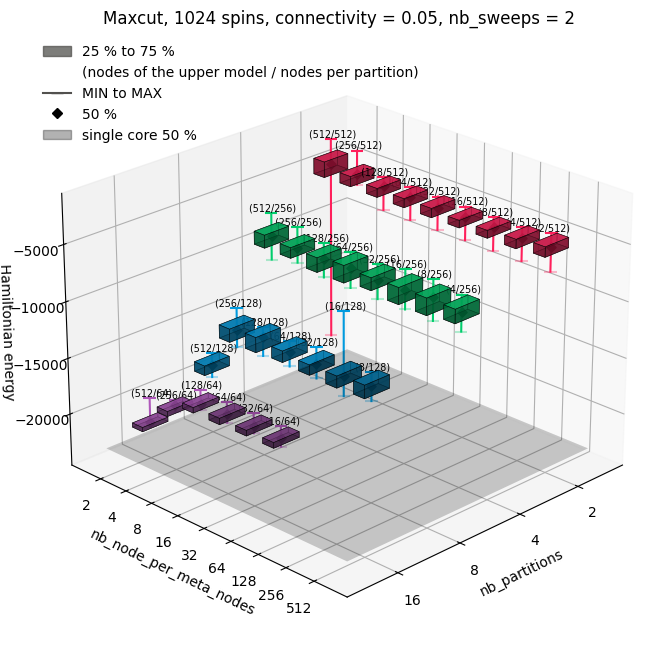

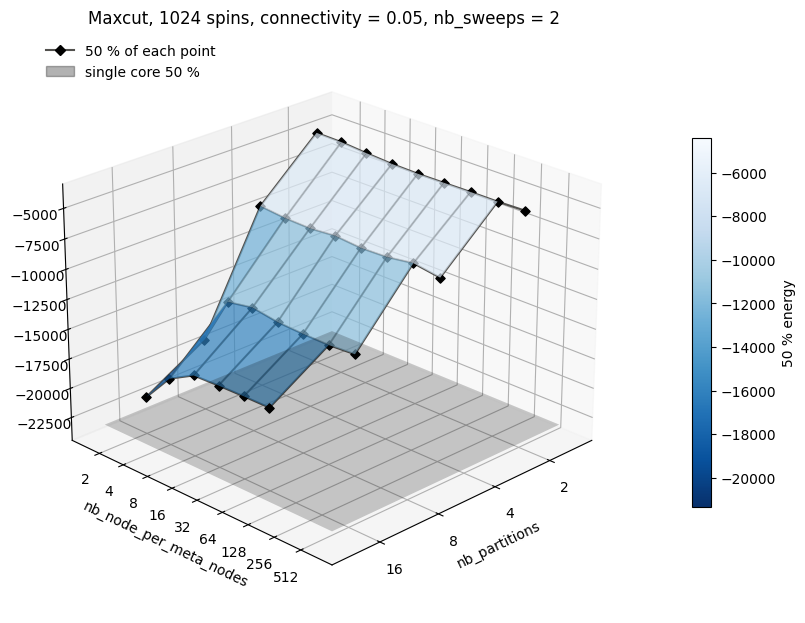

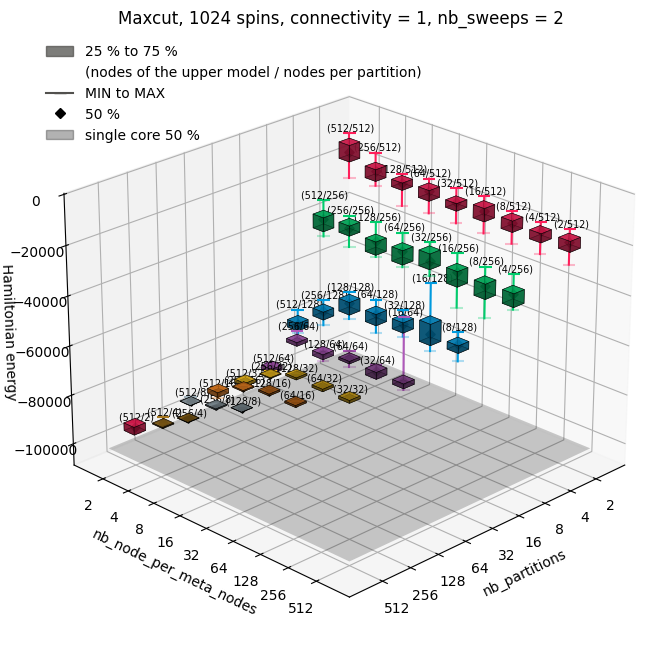

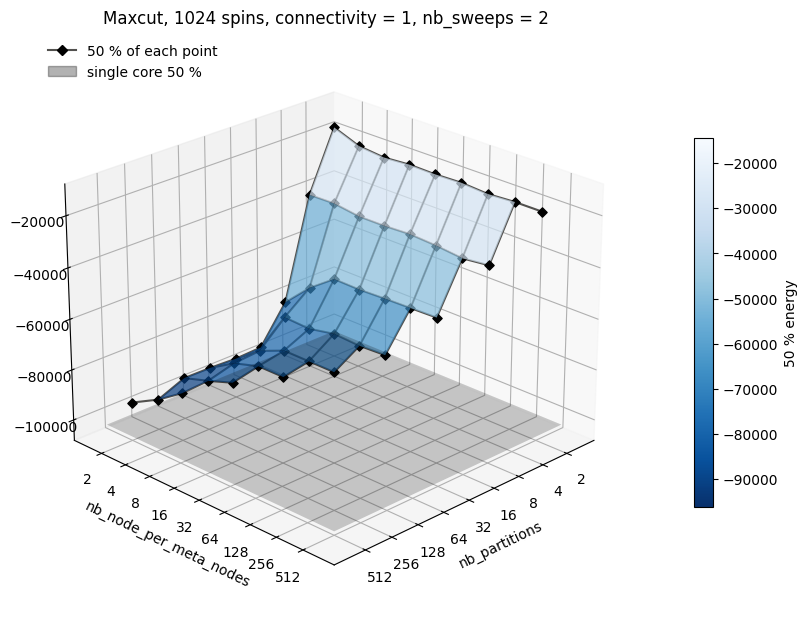

In [23]:
# MIN, 25 %, 50 %, 75 % and MAX of each point
fig = utils.plot_energy_3d(saved, y="nb_node_per_meta_nodes", connectivity =saved["connectivity"].min(), **fixed("nb_partitions", "nb_node_per_meta_nodes", "connectivity"))
fig = utils.plot_energy_3d_mean(saved, y="nb_node_per_meta_nodes", connectivity =saved["connectivity"].min(),   **fixed("nb_partitions", "nb_node_per_meta_nodes", "connectivity"))


fig = utils.plot_energy_3d(saved, y="nb_node_per_meta_nodes", connectivity =saved["connectivity"].max(), **fixed("nb_partitions", "nb_node_per_meta_nodes", "connectivity"))
fig = utils.plot_energy_3d_mean(saved, y="nb_node_per_meta_nodes", connectivity =saved["connectivity"].max(),   **fixed("nb_partitions", "nb_node_per_meta_nodes", "connectivity"))

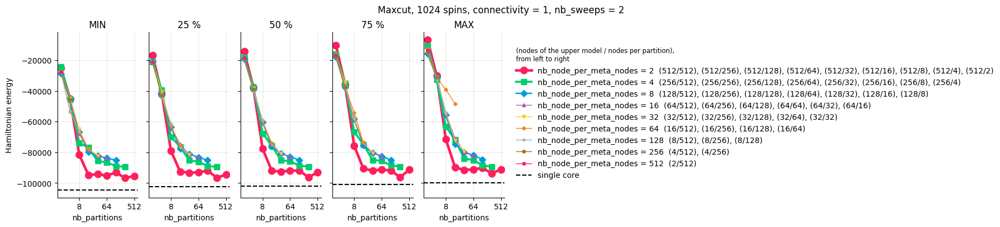

In [143]:
fig = utils.plot_energy_lines(saved, x="nb_partitions", by="nb_node_per_meta_nodes", relative=False, logscale=2, **fixed("nb_partitions", "nb_node_per_meta_nodes"))

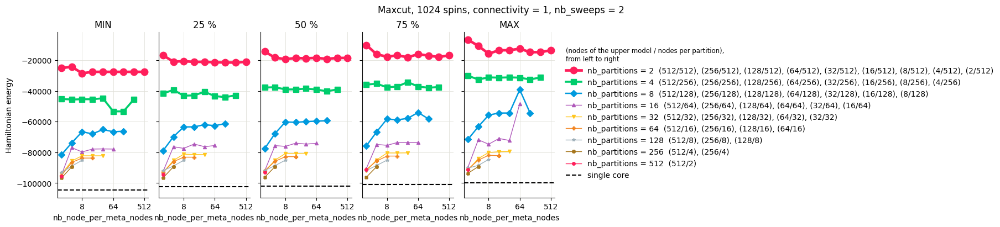

In [144]:
fig = utils.plot_energy_lines(saved, x="nb_node_per_meta_nodes", by="nb_partitions", relative=False,logscale=2, **fixed("nb_partitions", "nb_node_per_meta_nodes"))

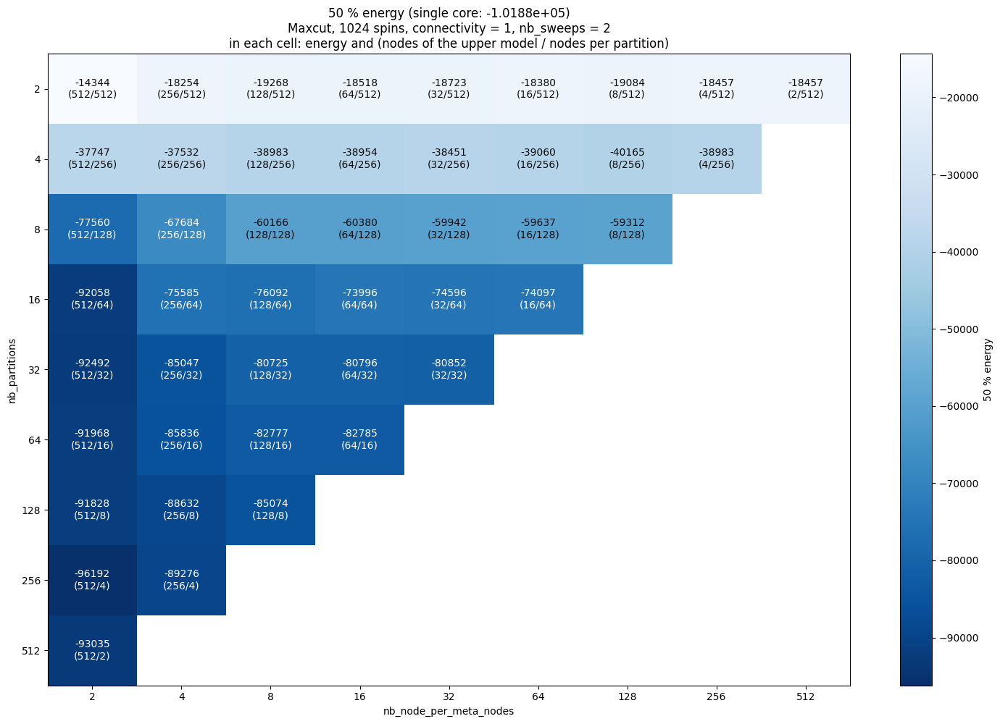

In [145]:
fig = utils.plot_energy_heatmap(saved, stat="en_50", **fixed("nb_partitions", "nb_node_per_meta_nodes"))

### Number of sweeps

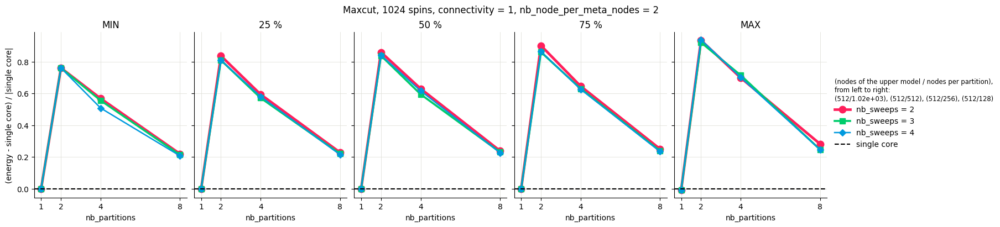

In [59]:
# Energy against the number of partitions, one line per number of sweeps
fig = utils.plot_energy_lines(saved, x="nb_partitions", by="nb_sweeps", relative=True, **fixed("nb_partitions", "nb_sweeps"))

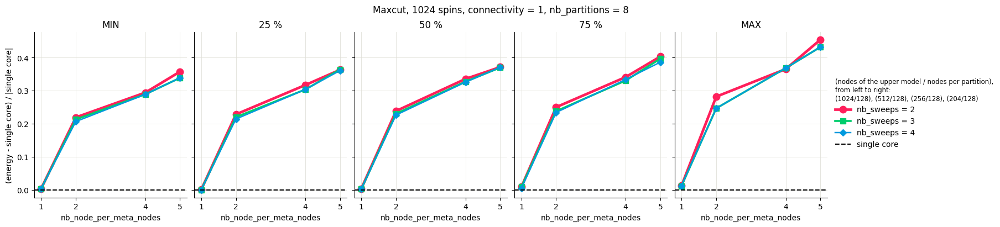

In [60]:
# Energy against the nodes per meta node at the selected number of partitions, one line per number of sweeps
fig = utils.plot_energy_lines(saved, x="nb_node_per_meta_nodes", by="nb_sweeps", relative=True, **fixed("nb_node_per_meta_nodes", "nb_sweeps"))

### Connectivity

One line per connectivity (one value only until `NB_CONNECTION_PER_SPIN` is a list). The energies of different connectivities are on different scales, so these are relative to the single-core run of the same problem: 0 is the single-core level, negative is better. `by="connections_per_spin"` gives the same lines labelled in connections per spin.

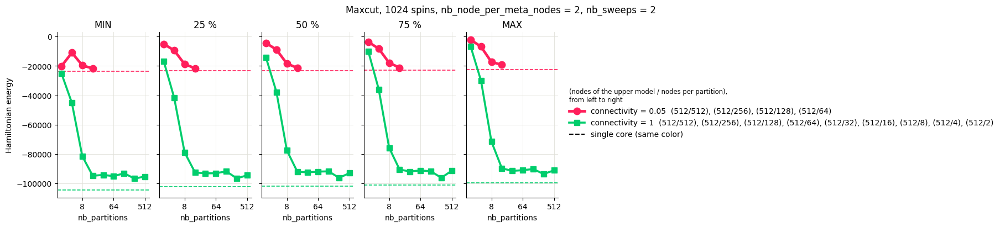

In [146]:
fig = utils.plot_energy_lines(saved, x="nb_partitions", by="connectivity", relative=False, logscale=2, **fixed("nb_partitions", "connectivity"))

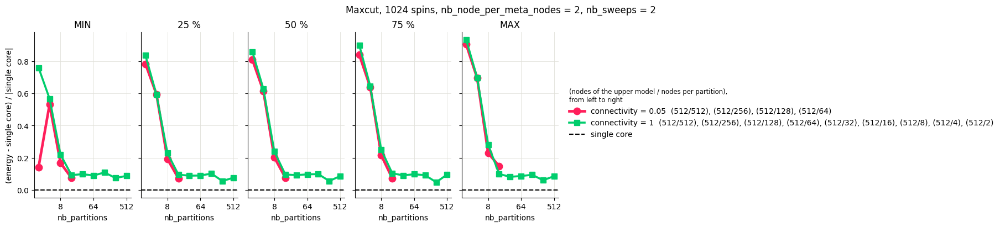

In [147]:
fig = utils.plot_energy_lines(saved, x="nb_partitions", by="connectivity", relative=True, logscale=2, **fixed("nb_partitions", "connectivity"))

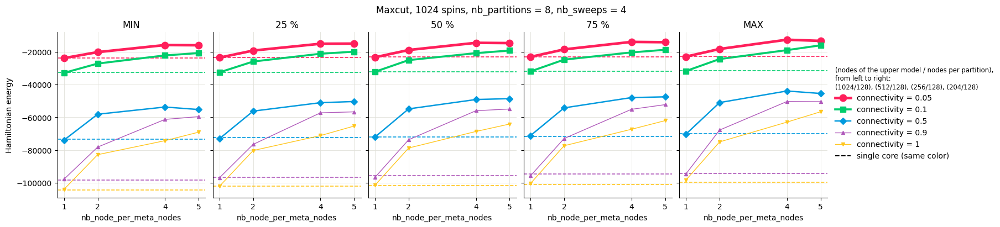

In [63]:
fig = utils.plot_energy_lines(saved, x="nb_node_per_meta_nodes", by="connectivity", relative=False, **fixed("nb_node_per_meta_nodes", "connectivity"))

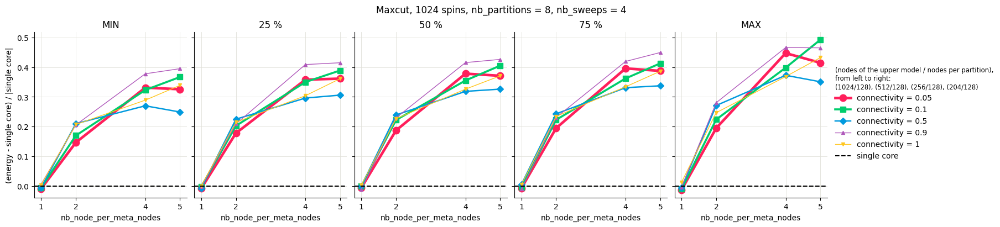

In [64]:
fig = utils.plot_energy_lines(saved, x="nb_node_per_meta_nodes", by="connectivity", relative=True, **fixed("nb_node_per_meta_nodes", "connectivity"))

### Model of the saved run

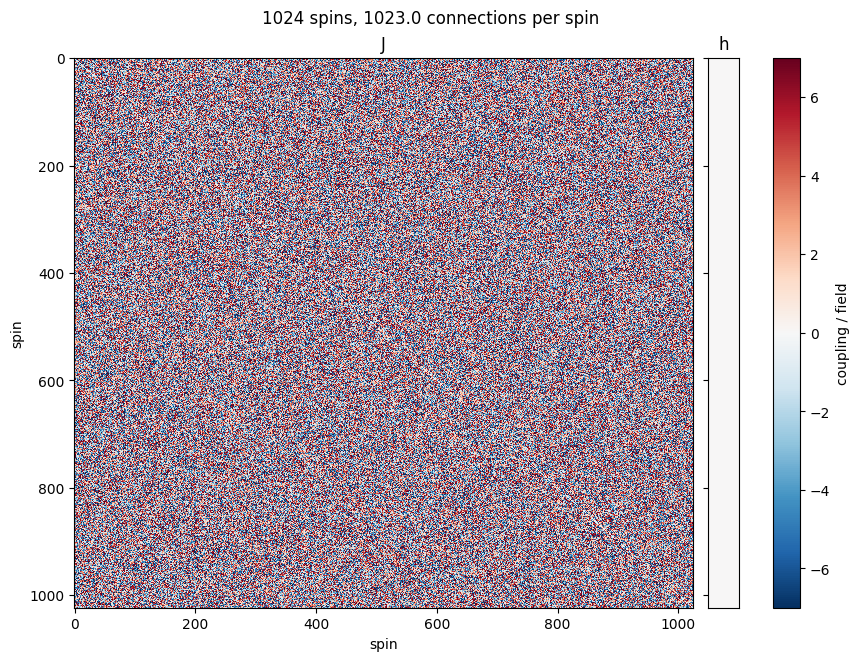

In [65]:
# J and h of the selected connectivity: the yaml regenerates the same problem
selected_config = dict(
    saved_config,
    dummy_connectivity=SELECTED["connectivity"],
    nb_sweeps_Hierarchical_solver=int(SELECTED["nb_sweeps"]),
)
fig = utils.plot_model(runs.generate_problem(selected_config)["ising_model"])

In [ ]:
# utils.save_figure(fig, csv_path.stem + "_model")   # to figures/, as pdf

In [77]:
selected_config 

{'SNR': 10,
 'T': 50.0,
 'T_final': 0.05,
 'T_final_SCA': 0.5,
 'T_final_inSituSA': 0.5,
 'T_init_SCA': 50.0,
 'a0': 1.0,
 'accumulation_delay': 0.0,
 'benchmark': './ising/benchmarks/MIMO/user5_ant5_M16.txt',
 'broadcast_delay': 0.0,
 'c0': 0.0,
 'capacitance': 1,
 'cluster_choice': 'random',
 'cluster_threshold': 0.3,
 'combine_nodes': False,
 'core_solver': 'Multiplicative',
 'coupling_annealing': True,
 'current': 1.0,
 'delay_offset': 0.0,
 'device_noise': False,
 'do_flipping': True,
 'dtBRIM': '1e-6',
 'dtbSB': 0.01,
 'dtdSB': 0.01,
 'dummy_ant_num': 64,
 'dummy_bit_width': 16,
 'dummy_case_num': 10,
 'dummy_connectivity': 1.0,
 'dummy_creator': True,
 'dummy_density': 1,
 'dummy_penalty_value': 1.0,
 'dummy_precision': 4,
 'dummy_qam': 4,
 'dummy_seed': 42,
 'dummy_size': 1024,
 'dummy_snr': 8,
 'dummy_spacing': 1.0,
 'dummy_user_num': 16,
 'dummy_weight_constant': 0.0,
 'eigenvalue_start': False,
 'end_cluster_size': 0.1,
 'exponent': 3.0,
 'gen_logfile': False,
 'init_cluster

## Extension: Louvain partitions against the partitions of a saved run

`COMPARE_RUN` is a saved run of generated problems, made with the partitioning of its yaml (`modularity` for the run below: the spins are cut in two equal halves again and again, so the number and the sizes of the partitions are the ones asked). The extension solves the same problems with the `louvain` partitioning, for each connectivity and each number of nodes per meta node at `LOUVAIN_SWEEPS` sweeps, and plays the plots of the saved run again with the louvain run added to them (`utile_louvain_compare.py`).

Louvain chooses the number and the sizes of its partitions itself: the number of partitions asked is not used. The partitioner runs louvain `LOUVAIN_RUNS` times (20, in `ising/utils/partitioning_schemes.py`) and keeps the split with the highest modularity, so a problem always gets the same split. `LOUVAIN_NB_PARTITIONS` is only the number written in the rows of the louvain run.

The extension takes its problems and its nodes per meta node from the saved run, not from the **Configuration** cell.

In [75]:
import utile_louvain_compare as louvain_compare

COMPARE_RUN = "Maxcut_N1024_c1-0.9-0.5-0.1-0.05_p1-2-4-8_m1-2-4-5_sweeps2-3-4_runs20_modularity_20261005_234422"   # a saved run of RESULTS_DIR: the file name without .csv
LOUVAIN_NB_PARTITIONS = 8         # written in the rows of the louvain run; louvain does not use it
LOUVAIN_DRAWS = 1                 # louvain splits measured per problem: one is enough, louvain returns the same split at each call
LOUVAIN_SWEEPS = 2                # sweeps of the louvain run: a number of sweeps of the saved run

compare_config, compare = utils.load_run(COMPARE_RUN, folder=RESULTS_DIR)
compare_technique = compare_config["partitioning_technique"]
compare_points = compare[compare["solver"] != utils.BASELINE_SOLVER]
connectivities = sorted((float(value) for value in compare["connectivity"].unique()), reverse=True)
meta_nodes = sorted(int(value) for value in compare_points["nb_node_per_meta_nodes"].unique())
partitions = sorted(int(value) for value in compare_points["nb_partitions"].unique() if value > 1)

# The config of the saved run with louvain in place of its partitioning: same problems, same solver settings
louvain_config = dict(
    compare_config,
    partitioning_technique="louvain",
    dummy_connectivity=connectivities[0],
    nb_sweeps_Hierarchical_solver=LOUVAIN_SWEEPS,
)
# The values the plots on one configuration use
EXTENSION_SELECTED = dict(
    connectivity=connectivities[0],
    nb_sweeps=LOUVAIN_SWEEPS,
    nb_partitions=8,
    nb_node_per_meta_nodes=2,
)
print(f"{compare_technique} run: connectivity {connectivities}, nodes per meta node {meta_nodes}, partitions {partitions}; louvain at {LOUVAIN_SWEEPS} sweeps")

modularity run: connectivity [1.0, 0.9, 0.5, 0.1, 0.05], nodes per meta node [1, 2, 4, 5], partitions [2, 4, 8]; louvain at 2 sweeps


### Louvain split, before any solve

What each partitioner makes of each problem: how many partitions (smallest, mean and largest number over the splits), the smallest and the largest partition, and `cut_share`: the share of the coupling weight |J| that links two different partitions, which is what the partitions do not see of each other while they are solved. `cut_share_random` is what partitions of the same sizes drawn at random cut on average: a partitioner that finds a structure in the problem is below it.

In [76]:
extension_problems = {value: runs.generate_problem(dict(louvain_config, dummy_connectivity=value)) for value in connectivities}
partition_rows = []
for extension_problem in extension_problems.values():
    partition_rows += runs.measure_partitions(extension_problem, "louvain", LOUVAIN_NB_PARTITIONS, nb_draws=LOUVAIN_DRAWS)
    for nb_partitions in partitions:
        partition_rows += runs.measure_partitions(extension_problem, compare_technique, nb_partitions)
partition_table = louvain_compare.partition_summary(partition_rows)
partition_table

,connectivity,partitioning,nb_partitions_asked,splits,partitions_min,partitions_mean,partitions_max,smallest,largest,cut_share,cut_share_random
0,1.00,louvain,8,1,7,7.0,7,80,185,0.850833,0.851284
1,1.00,modularity,2,1,2,2.0,2,512,512,0.500646,0.500489
2,1.00,modularity,4,1,4,4.0,4,256,256,0.750738,0.750733
3,1.00,modularity,8,1,8,8.0,8,128,128,0.875550,0.875855
4,0.90,louvain,8,1,6,6.0,6,131,209,0.828733,0.829442
5,0.90,modularity,2,1,2,2.0,2,512,512,0.500800,0.500489
6,0.90,modularity,4,1,4,4.0,4,256,256,0.750420,0.750733
7,0.90,modularity,8,1,8,8.0,8,128,128,0.875085,0.875855
8,0.50,louvain,8,1,6,6.0,6,127,202,0.827487,0.829584
9,0.50,modularity,2,1,2,2.0,2,512,512,0.501643,0.500489


The `J` of the selected problem with its spins ordered partition after partition, for the louvain split and for the partitions of the saved run. The squares on the diagonal are what a partition solves; the rest links two partitions.

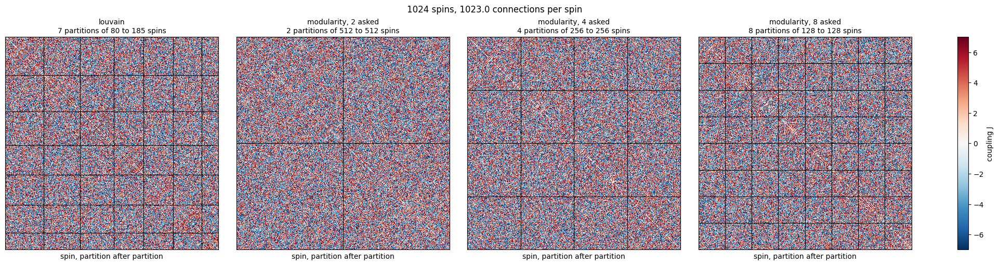

In [77]:
selected_problem = extension_problems[EXTENSION_SELECTED["connectivity"]]
splits = {"louvain": runs.make_partitioning(selected_problem, LOUVAIN_NB_PARTITIONS, "louvain")}
for nb_partitions in partitions:
    splits[f"{compare_technique}, {nb_partitions} asked"] = runs.make_partitioning(selected_problem, nb_partitions, compare_technique)
fig = louvain_compare.plot_partitions(selected_problem["ising_model"], splits)

The hierarchy of the louvain split, as the solver builds it before the first sweep.

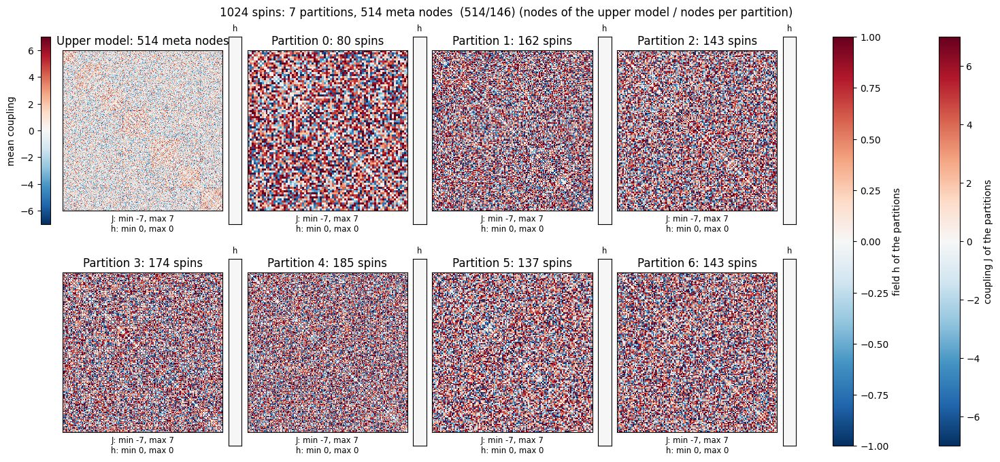

In [78]:
louvain_hierarchy = runs.build_hierarchy(selected_problem, LOUVAIN_NB_PARTITIONS, EXTENSION_SELECTED["nb_node_per_meta_nodes"])
fig = utils.plot_hierarchy(louvain_hierarchy)

### Louvain run

One point per number of nodes per meta node, on the problem of every connectivity of the saved run, at `LOUVAIN_SWEEPS` sweeps. The single-core baseline is not solved again: the plots take it from the saved run. The run is saved like the others, but `last_run` is left on the run it points to.

In [24]:
louvain_grid = [(LOUVAIN_NB_PARTITIONS, value) for value in meta_nodes]
louvain_frame = runs.run_study(louvain_config, louvain_grid, nb_sweeps=LOUVAIN_SWEEPS, connectivity=connectivities, nb_workers=NB_WORKERS, nice=NICE)
_, louvain_csv_path = utils.save_run(louvain_config, louvain_frame, RESULTS_DIR, link_last=False)
LOUVAIN_RUN = louvain_csv_path.stem
print(LOUVAIN_RUN)

connectivity 1.0: 1024 spins, 1023.0 connections per spin


Grid points: 100%|██████████| 4/4 [06:11<00:00, 92.83s/it] 


connectivity 0.9: 1024 spins, 920.5 connections per spin


Grid points: 100%|██████████| 4/4 [06:59<00:00, 104.93s/it]


connectivity 0.5: 1024 spins, 511.5 connections per spin


...

connectivity 0.1: 1024 spins, 101.8 connections per spin


Grid points: 100%|██████████| 4/4 [05:11<00:00, 77.77s/it] 


connectivity 0.05: 1024 spins, 50.9 connections per spin


Grid points: 100%|██████████| 4/4 [05:14<00:00, 78.73s/it] 


Maxcut_N1024_c1-0.9-0.5-0.1-0.05_p8_m1-2-4-5_sweeps2_runs20_louvain_20261006_142041


### The plots of the saved run, with louvain

The plots of **Plots, from the saved csv** again, on the saved run, with the louvain run added where it applies: louvain has no number of partitions and one number of sweeps. Its lines are dotted, and its name comes with the number of partitions louvain made of the problem, from the table above. Against `nb_partitions` it is a horizontal line; in the 3D plot and in the heatmap it is one more position after the largest number of partitions.

`LOUVAIN_RUN = "<name>"` (the file name without `.csv`) plots an older louvain run without solving it again.

In [79]:
_, louvain = utils.load_run(LOUVAIN_RUN, folder=RESULTS_DIR)


def extension_fixed(*spread):
    return {name: value for name, value in EXTENSION_SELECTED.items() if name not in spread}

#### Partitions and nodes per meta node

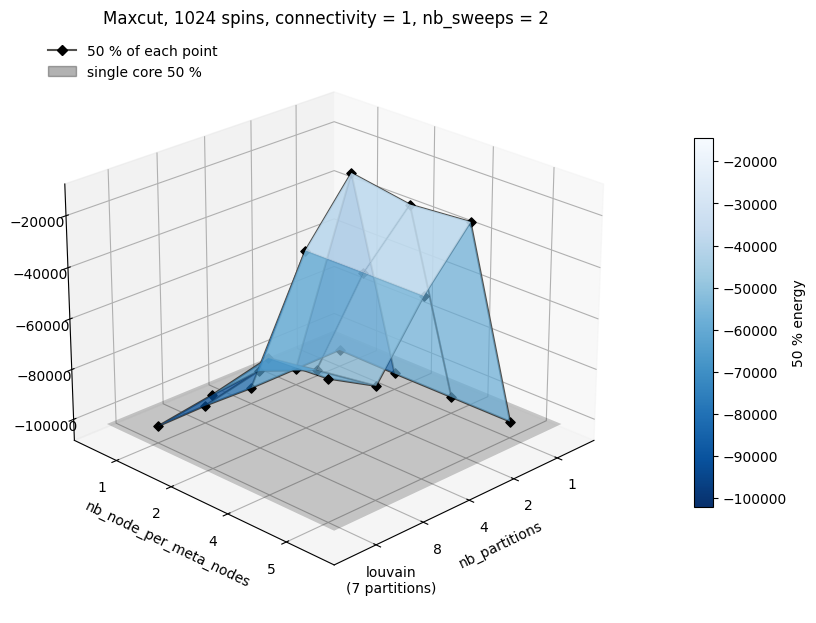

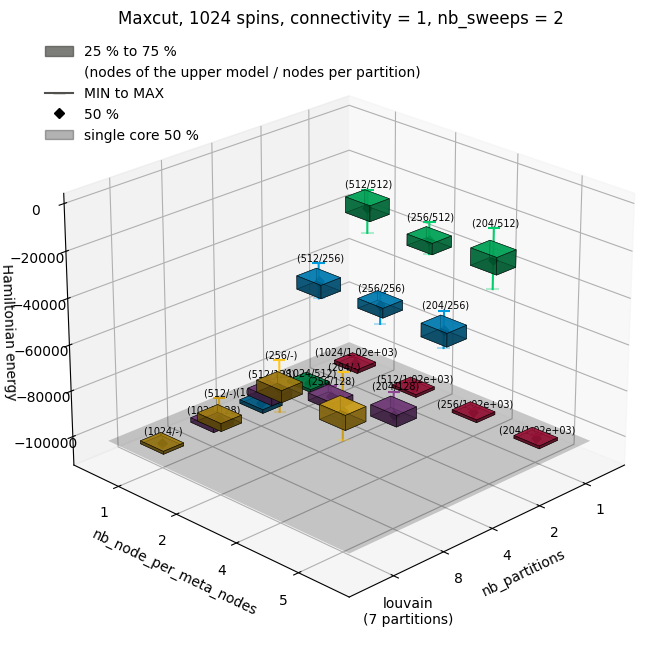

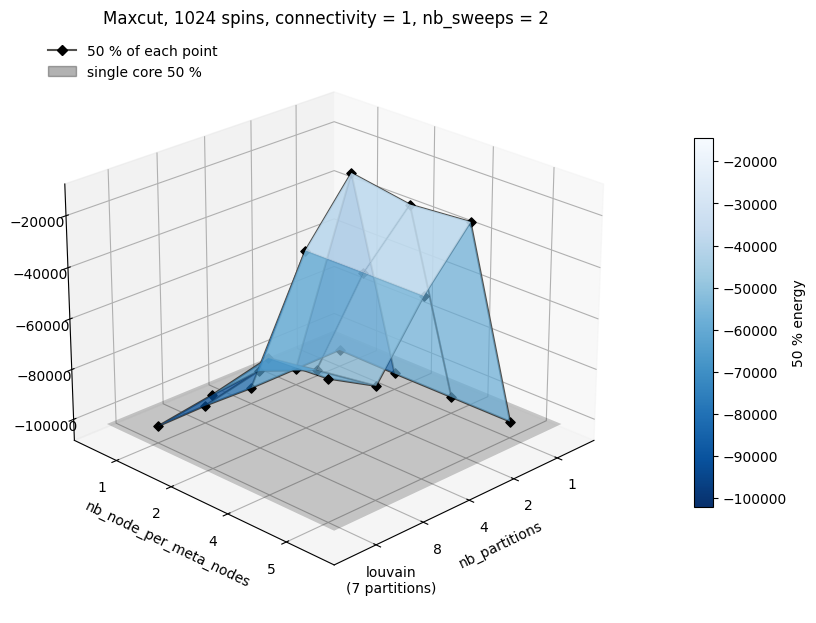

In [102]:
# MIN, 25 %, 50 %, 75 % and MAX of each point
fig = louvain_compare.plot_energy_3d(compare, louvain, partitions=partition_table, y="nb_node_per_meta_nodes", **extension_fixed("nb_partitions", "nb_node_per_meta_nodes"))
louvain_compare.plot_energy_3d_mean(compare, louvain, partitions=partition_table, y="nb_node_per_meta_nodes", **extension_fixed("nb_partitions", "nb_node_per_meta_nodes"))

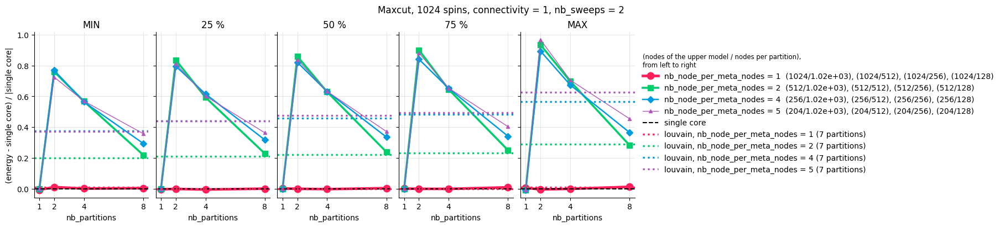

In [81]:
fig = louvain_compare.plot_energy_lines(compare, louvain, partitions=partition_table, x="nb_partitions", by="nb_node_per_meta_nodes", relative=True, **extension_fixed("nb_partitions", "nb_node_per_meta_nodes"))

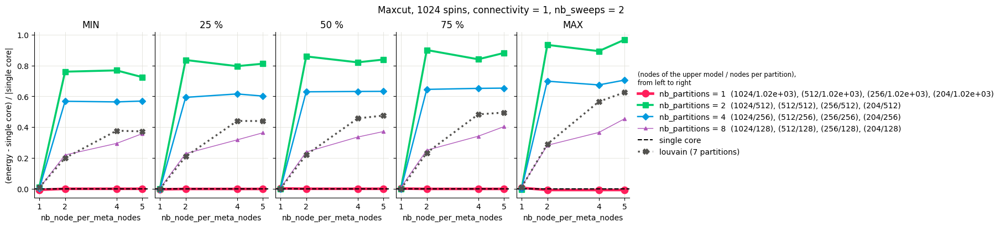

In [90]:
fig = louvain_compare.plot_energy_lines(compare, louvain, partitions=partition_table, x="nb_node_per_meta_nodes", by="nb_partitions", relative=True, **extension_fixed("nb_partitions", "nb_node_per_meta_nodes"))

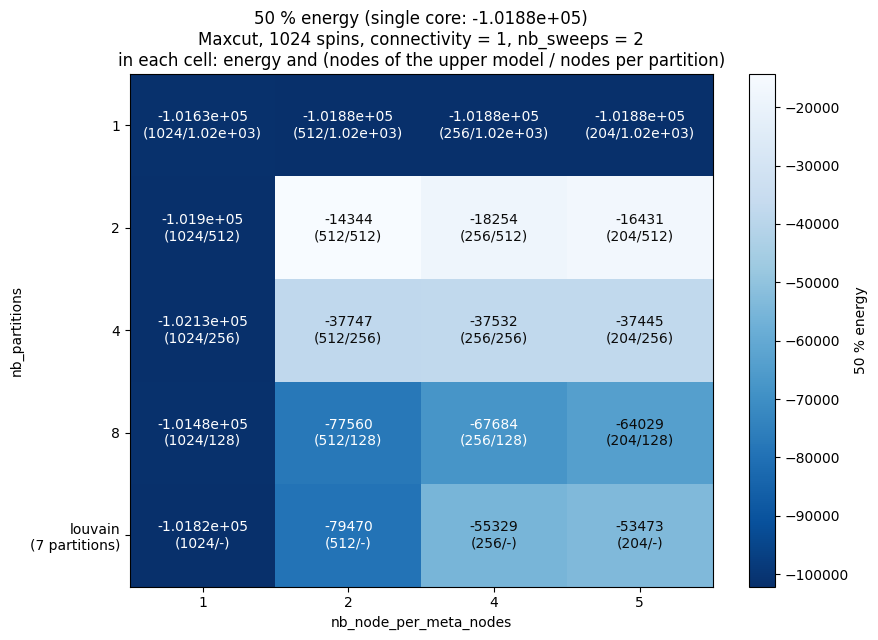

In [83]:
fig = louvain_compare.plot_energy_heatmap(compare, louvain, partitions=partition_table, stat="en_50", **extension_fixed("nb_partitions", "nb_node_per_meta_nodes"))

#### Number of sweeps

Louvain is run at `LOUVAIN_SWEEPS` sweeps: it is added to the line of that number of sweeps only.

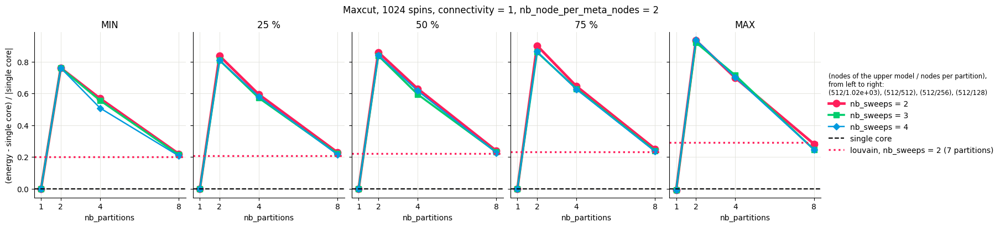

In [84]:
# Energy against the number of partitions, one line per number of sweeps
fig = louvain_compare.plot_energy_lines(compare, louvain, partitions=partition_table, x="nb_partitions", by="nb_sweeps", relative=True, **extension_fixed("nb_partitions", "nb_sweeps"))

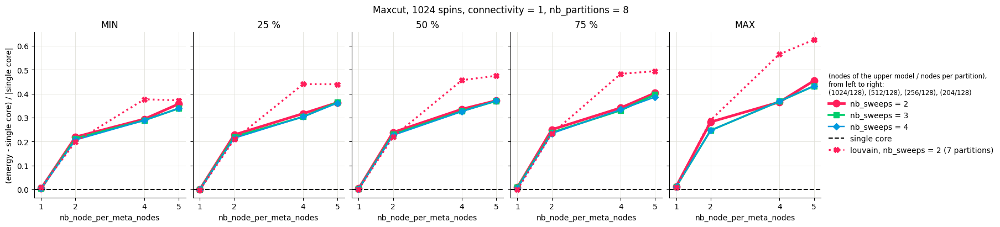

In [85]:
# Energy against the nodes per meta node at the selected number of partitions, one line per number of sweeps
fig = louvain_compare.plot_energy_lines(compare, louvain, partitions=partition_table, x="nb_node_per_meta_nodes", by="nb_sweeps", relative=True, **extension_fixed("nb_node_per_meta_nodes", "nb_sweeps"))

#### Connectivity

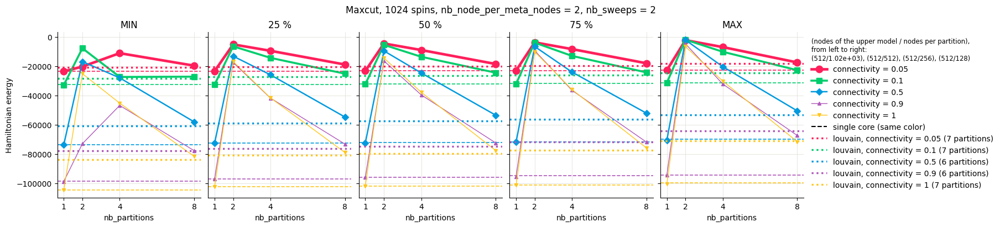

In [86]:
fig = louvain_compare.plot_energy_lines(compare, louvain, partitions=partition_table, x="nb_partitions", by="connectivity", relative=False, **extension_fixed("nb_partitions", "connectivity"))

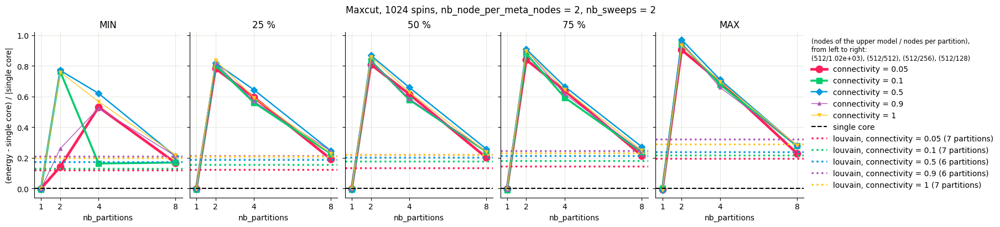

In [87]:
fig = louvain_compare.plot_energy_lines(compare, louvain, partitions=partition_table, x="nb_partitions", by="connectivity", relative=True, **extension_fixed("nb_partitions", "connectivity"))

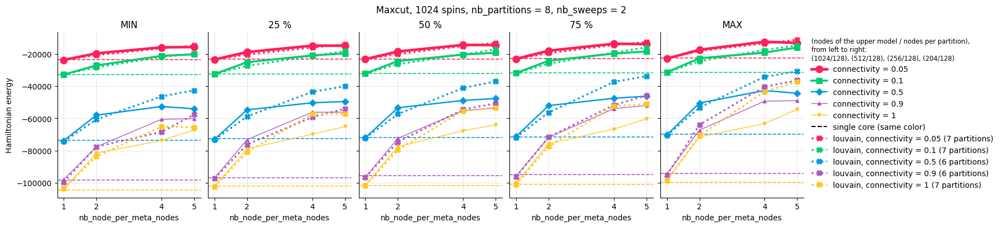

In [88]:
fig = louvain_compare.plot_energy_lines(compare, louvain, partitions=partition_table, x="nb_node_per_meta_nodes", by="connectivity", relative=False, **extension_fixed("nb_node_per_meta_nodes", "connectivity"))

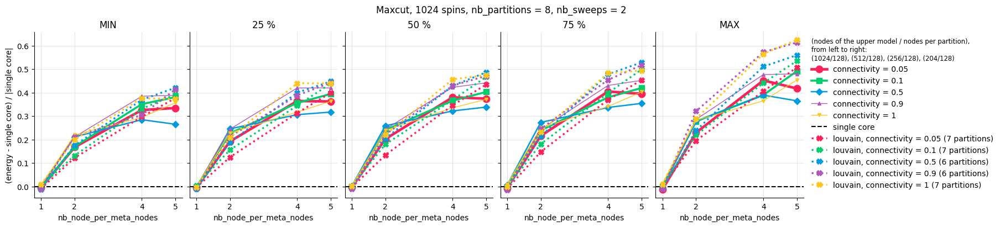

In [89]:
fig = louvain_compare.plot_energy_lines(compare, louvain, partitions=partition_table, x="nb_node_per_meta_nodes", by="connectivity", relative=True, **extension_fixed("nb_node_per_meta_nodes", "connectivity"))